# Applied Statistics Assessment

This notebook contains solutions for the Applied Statistics assessment, including:

1. Lady Tasting Tea experiment (original 8-cup and extended 12-cup design)  
2. Type II error and power simulations for t-tests  
3. Normal distribution exploration: sample vs population SD  
4. ANOVA: comparing multiple group means  

All simulations are performed in Python with reproducible random seeds. Visualizations are included to support interpretations.

****

#### Data Frames and Libraries


In [116]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.formula.api import ols
import seaborn as sns
import math
import random
import itertools
import scipy.stats as stats
import statsmodels as sm
from statsmodels.stats.anova import anova_lm

## Problem 1: Extending the Lady Tasting Tea

Original 8-cup experiment and extended 12-cup design. 
Estimate the probability of correctly identifying all cups by chance using simulation and compare with the exact combinatorial probability.

*******

### Extended Experiment (Simulation Approach)

##### Background

In the original Lady Tasting Tea experiment, there are 8 cups:
- 4 with milk poured first
- 4 with tea poured first

Under the null hypothesis that the participant is guessing randomly, all possible arrangements of the milk-first cups are equally likely.

We extend this experiment to 12 cups, with:
- 4 milk-first
- 8 tea-first

and estimate the probability of perfect identification by simulation.

##### Original 8-Cup Experiment:

In [75]:
# Set seed for reproducibility
np.random.seed(42)
# Number of Monte Carlo simulations
n_simulations = 100_000

# Original setup
cups_8 = 8
milk_8 = 4
tea_8 = 4

# True configuration: 1 = milk first, 0 = tea first
true_8 = np.array([1]*milk_8 + [0]*tea_8)

# Counter for perfect classifications
correct_8 = 0

# Simulate random guessing under the null hypothesis
for _ in range(n_simulations):
    # Randomly shuffle the cup labels
    guess = np.random.permutation(true_8)
    # Check if all cups are correctly identified
    if np.array_equal(guess, true_8):
        correct_8 += 1

# Estimated probability of a perfect guess by chance
prob_8_sim = correct_8 / n_simulations
prob_8_sim


0.01459

In [76]:
# Exact probability of a perfect guess in the 8-cup experiment
# (1 divided by the number of possible arrangements)
prob_8_exact = 1 / math.comb(8, 4)
prob_8_exact

0.014285714285714285

Extended 12-Cup Experiment: Simulation

In [77]:
# Number of cups of tea in total.
no_cups = 12
# Number of cups of tea with tea in first.
no_cups_tea_first = 8
# Number of cups of tea with milk in first.
no_cups_milk_first = 4



In [78]:
# Number of possible arrangements
ways = math.comb(no_cups, no_cups_milk_first)

# Show.
ways

495

In [79]:
# True configuration: 1 = milk first, 0 = tea first
true_12 = np.array([1]*no_cups_milk_first + [0]*no_cups_tea_first)

# Counter for perfect guesses
correct_12 = 0

for _ in range(n_simulations):
    # Random guess by shuffling labels
    guess = np.random.permutation(true_12)
    
    # Check if guess matches the true configuration
    if np.array_equal(guess, true_12):
        correct += 1

# Estimated probability of correct identification by chance
prob_12 = correct / n_simulations
prob_12


0.00773

In [80]:
# Exact probability of a perfect guess in the 12-cup experiment
# (1 divided by the number of possible arrangements)
prob_12_exact = 1 / math.comb(12, 4)
prob_12_exact

0.00202020202020202

In [81]:
# Cup labels
labels = list(range(no_cups))

# All combinations of milk-first cups
combs = list(itertools.combinations(labels, no_cups_milk_first))

# Random guess of milk-first cups
labels_milk = random.sample(labels, 4)
labels_milk.sort()
labels_milk

[5, 6, 7, 8]

In [82]:
no_overlaps = []

# Loop through the combinations.
for comb in combs:
  # Turn comb into a set.
  s1 = set(comb)
  # Turn labels_milk into a set.
  s2 = set(labels_milk)
  # Figure out where they overlap.
  overlap = s1.intersection(s2)
  # Append overlap to no_overlaps.
  no_overlaps.append(len(overlap))


In [83]:
# Count the number of times each overlap occurs.
counts = np.unique(no_overlaps, return_counts=True)

# Show.
counts

(array([0, 1, 2, 3, 4]), array([ 70, 224, 168,  32,   1], dtype=int64))

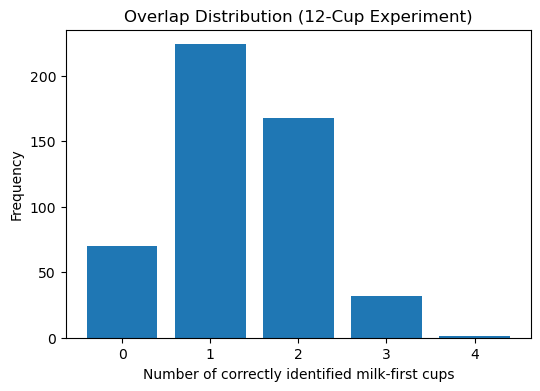

In [84]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(6, 4))
# Bar chart of overlap counts
ax.bar(counts[0], counts[1])
ax.set_xlabel("Number of correctly identified milk-first cups")
ax.set_ylabel("Frequency")
ax.set_title("Overlap Distribution (12-Cup Experiment)")
plt.show()

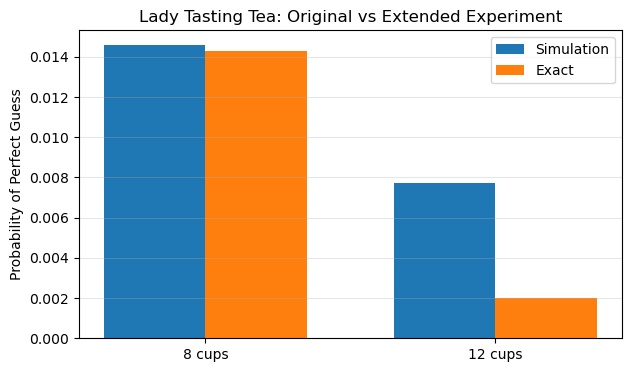

In [85]:
# Probabilities estimated by simulation
labels = ["8 cups", "12 cups"]
sim_probs = [prob_8_sim, prob_12]
# Exact probabilities from combinatorics
exact_probs = [prob_8_exact, prob_12_exact]
# Bar positions
x = np.arange(len(labels))
width = 0.35


# Create comparison bar chart
plt.figure(figsize=(7, 4))
plt.bar(x - width/2, sim_probs, width, label="Simulation")
plt.bar(x + width/2, exact_probs, width, label="Exact")

plt.xticks(x, labels)
plt.ylabel("Probability of Perfect Guess")
plt.title("Lady Tasting Tea: Original vs Extended Experiment")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


***

#### Simulation Process

In the original Lady Tasting Tea experiment, there are 8 cups: 4 with milk poured first and 4 with tea poured first. Under the null hypothesis that the participant is guessing randomly, the probability of correctly identifying all cups is equal to the reciprocal of the number of possible arrangements, this corresponds to
1 divided by 70, which is approximately 0.014.

To extend this experiment, we considered a scenario with 12 cups: 8 tea-first and 4 milk-first. As before, all possible arrangements of the milk-first cups are assumed equally likely under random guessing.

Using a Monte Carlo simulation, the true configuration of cups was fixed, and random guesses were generated by repeatedly shuffling the labels. For each simulation, we checked whether the random guess exactly matched the true configuration. The probability of a correct identification by chance was estimated as the proportion of simulations in which all cups were correctly classified.

The same simulation procedure was applied to both the 12-cup experiment and the original 8-cup experiment to allow direct comparison.

*****

#### Results and Interpretation

The estimated probability of correctly identifying all cups by chance in the 12-cup experiment is substantially smaller than in the original 8-cup design. This is expected, as increasing the number of cups greatly increases the number of possible configurations.

The simulation results closely match the exact probabilities computed using combinatorics, confirming the validity of the simulation approach.

Because the probability of success by chance is much lower in the extended experiment, observing a perfect classification would provide stronger evidence against the null hypothesis. This suggests that the original p-value threshold of 0.05 may already be conservative in the extended design, and there is less justification for relaxing it compared to the original experiment.


****

#### References:
- [Code Base](https://github.com/ianmcloughlin/applied-statistics/blob/main/materials/lady-tasting-tea.ipynb)
- [Random](https://docs.python.org/3/library/random.html#random.sample)
- [Sets](https://docs.python.org/3/tutorial/datastructures.html#sets)

****

## Problem 2: Normal Distribution

Simulate Type II errors and power for independent samples t-tests, comparing Student and Welch tests. Explore effect of varying mean differences and sample sizes.

*******

Generate Samples and Compute SD

In [86]:
# Generating samples
n_samples = 100_000
sample_size = 10

# Generate a 100,000 × 10 array of standard normal samples
data = np.random.normal(loc=0, scale=1, size=(n_samples, sample_size))

In [87]:
# Compute standard deviations

# Population standard deviation (ddof=0)
pop_sd = np.std(data, axis=1, ddof=0)

# Sample standard deviation (ddof=1)
sample_sd = np.std(data, axis=1, ddof=1)

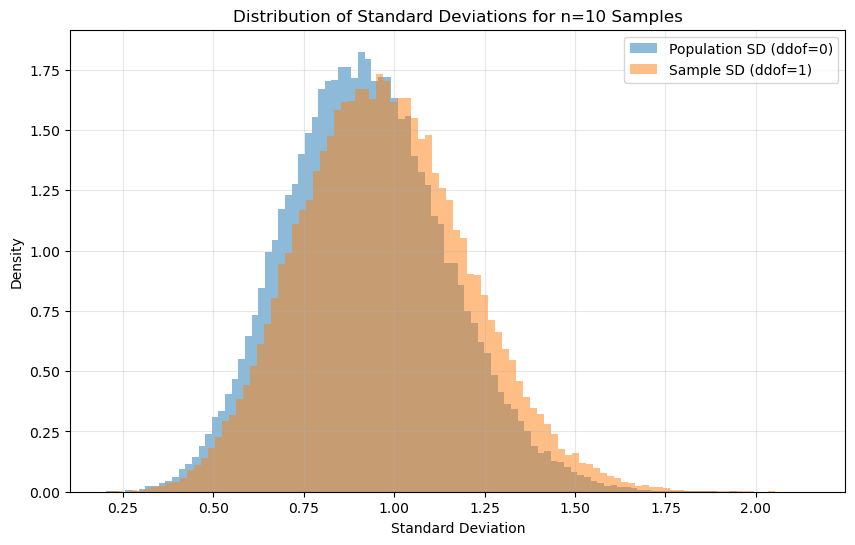

In [88]:
# Plot histograms

plt.figure(figsize=(10, 6))

plt.hist(pop_sd, bins=100, alpha=0.5, label='Population SD (ddof=0)', density=True)
plt.hist(sample_sd, bins=100, alpha=0.5, label='Sample SD (ddof=1)', density=True)

plt.title("Distribution of Standard Deviations for n=10 Samples")
plt.xlabel("Standard Deviation")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

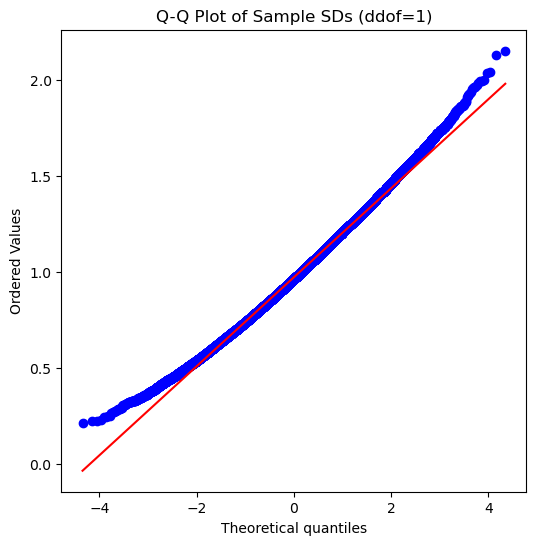

In [89]:
# Create an empty plot
fig, ax = plt.subplots(figsize=(6, 6))

# Q-Q plot of the sample standard deviations
stats.probplot(sample_sd, dist="norm", plot=ax)

ax.set_title("Q-Q Plot of Sample SDs (ddof=1)")
plt.show()

****

#### Description of the Simulation

We generate 100,000 independent samples of size n=10 from the standard normal distribution. For each sample, two estimates of the standard deviation are computed:

- The population standard deviation using ddof = 0, and
- The sample standard deviation using ddof = 1, which applies Bessel’s correction.

Histograms of both sets of standard deviations are plotted on the same axes to compare their empirical distributions.

****

#### Observed Differences

- The distribution of the sample standard deviation (ddof = 1) is shifted slightly to the right compared to the population standard deviation.

- This occurs because Bessel’s correction divides by n−1 instead of n, inflating the variance estimate to correct for the downward bias resent in the population estimator.

- The sample SD distribution is therefore less biased but exhibits slightly greater variability.

- Both distributions are right-skewed and are clearly non-normal, as confirmed by the Q–Q plot.

****

#### Effect of Increasing Sample Size

If the sample size were increased:
- The difference between the two distributions would decrease.
- Both estimators would concentrate more tightly around the true population standard deviation (σ=1).
- The bias of the population SD estimator would become negligible.
- The sampling variability of both estimators would decrease, resulting in narrower histograms.
- In the limit as n→∞, the population and sample standard deviation estimators converge and become nearly indistinguishable.

****

#### Key Statistical Takeaway

Bessel’s correction (ddof = 1) corrects bias in variance estimation for small samples. The effect is noticeable for small n, but diminishes as sample size increases.

****

#### Increase Sample size.

To further explore the behavior of the standard deviation estimators, the simulation was repeated for increasing sample sizes. As the sample size increases, both the population and sample standard deviation estimators converge to the true population value (σ = 1). The difference between the two estimators becomes negligible for larger samples, illustrating that the bias of the population standard deviation is mainly a small-sample issue.

In [90]:
# Reproducibility
np.random.seed(42)

# Simulation settings
n_samples = 100_000
sample_sizes = [5, 10, 30, 50, 100]

mean_pop_sd = []
mean_sample_sd = []

In [91]:
for n in sample_sizes:
    # Generate samples
    data = np.random.normal(0, 1, size=(n_samples, n))
    
    # Compute SDs
    pop_sd = np.std(data, axis=1, ddof=0)
    sample_sd = np.std(data, axis=1, ddof=1)
    
    # Store average SDs
    mean_pop_sd.append(np.mean(pop_sd))
    mean_sample_sd.append(np.mean(sample_sd))


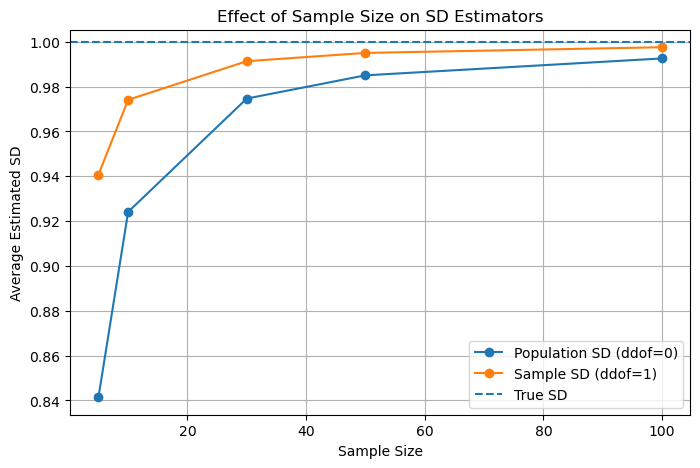

In [92]:

# Plot average SD estimates vs sample size
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, mean_pop_sd, marker='o', label="Population SD (ddof=0)")
plt.plot(sample_sizes, mean_sample_sd, marker='o', label="Sample SD (ddof=1)")
plt.axhline(1, linestyle='--', label="True SD")
plt.xlabel("Sample Size")
plt.ylabel("Average Estimated SD")
plt.title("Effect of Sample Size on SD Estimators")
plt.legend()
plt.grid(True)
plt.show()

******

#### References:
- [Base Code](https://github.com/ianmcloughlin/applied-statistics/blob/main/materials/normal-distribution.ipynb)
- [Numpy.std](https://numpy.org/doc/stable/reference/generated/numpy.std.html)
- [Numpy Random Normal](https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html)
- [ddof](https://stackoverflow.com/questions/27600207/why-does-numpy-std-give-a-different-result-to-matlab-std)

****

## Problem 3: t-Tests

Generate many samples from standard normal distribution. Compare sample (ddof=1) vs population (ddof=0) standard deviations. Visualize distributions.
****

In [93]:

# Reproducibility
np.random.seed(42)
n = 100                    # sample size per group
n_simulations = 1000       # repetitions per mean difference
alpha = 0.05               # significance level
# Mean differences to test
delta_values = np.arange(0, 1.1, 0.1)

In [94]:
#Estimate the Type II error rate for an independent samples t-test when the true difference in means is delta.
def type_ii_error_rate(delta, n=100, n_simulations=1000, alpha=0.05):
    failures = 0  
    for _ in range(n_simulations):
        # Sample from N(0, 1)
        x = np.random.normal(0, 1, n)
        
        # Sample from N(delta, 1)
        y = np.random.normal(delta, 1, n)
        
        # Perform independent samples t-test
        _, p_value = ttest_ind(x, y, equal_var=True)
        
        # Fail to reject the null hypothesis
        if p_value >= alpha:
            failures += 1
    
    return failures / n_simulations

In [95]:
type_ii_errors = np.array([
    type_ii_error_rate(delta) for delta in delta_values
])

# Corresponding power values
power = 1 - type_ii_errors

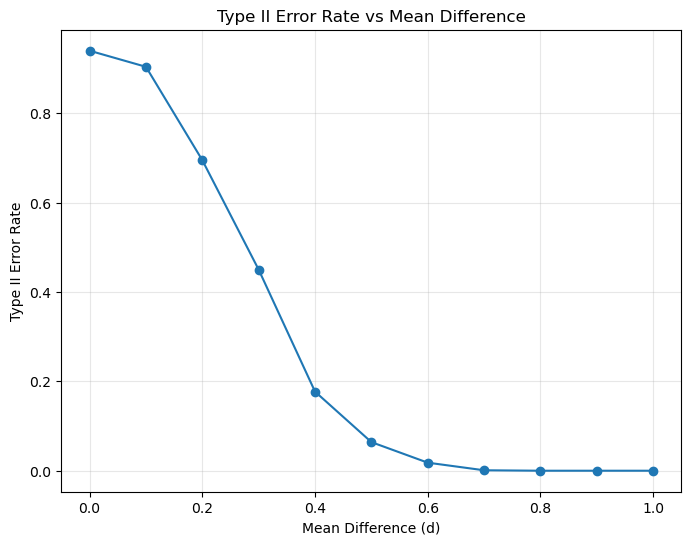

In [96]:
#Plot Rate vs Mean Difference
plt.figure(figsize=(8, 6))

plt.plot(delta_values, type_ii_errors, marker='o')
plt.xlabel("Mean Difference (d)")
plt.ylabel("Type II Error Rate")
plt.title("Type II Error Rate vs Mean Difference")
plt.grid(alpha=0.3)

plt.show()

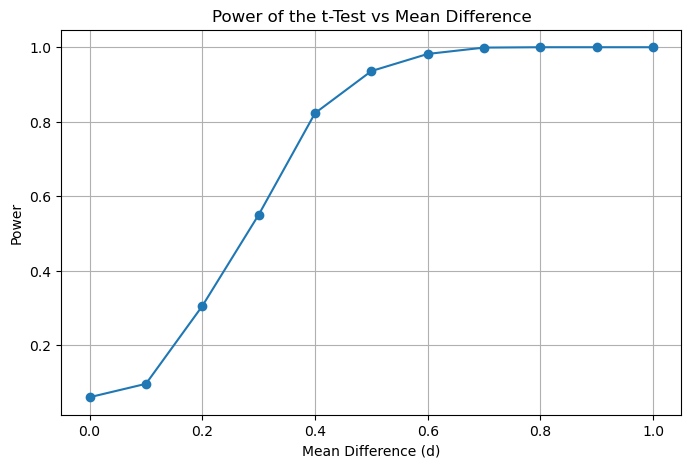

In [97]:
#Plot t-Test vs Mean difference

plt.figure(figsize=(8, 5))
plt.plot(delta_values, power, marker='o')
plt.xlabel("Mean Difference (d)")
plt.ylabel("Power")
plt.title("Power of the t-Test vs Mean Difference")
plt.grid(True)
plt.show()

In [98]:
# Set random seed for reproducibility
np.random.seed(42)

# Define parameters
n = 100                           # Sample size for each group
n_simulations = 1000              # Number of simulations to estimate Type II error
alpha = 0.05                       # Significance level (probability of Type I error)
mean_differences = np.arange(0, 1.1, 0.1)  # Range of mean differences (delta) to test

# Initialize a list to store Type II error rates
type_ii_errors = []


In [99]:
# Loop over different mean differences
for d in mean_differences:
    failures = 0  # Counter for simulations where the null hypothesis is not rejected
    for _ in range(n_simulations):
        # Generate two independent samples from normal distributions
        x = np.random.normal(0, 1, n)   # Sample from N(0,1)
        y = np.random.normal(d, 1, n)   # Sample from N(d,1), mean shifted by d
        
        # Perform independent two-sample t-test
        _, p = ttest_ind(x, y)
        
        # Check if null hypothesis is not rejected (p-value >= alpha)
        if p >= alpha:
            failures += 1
    
    # Estimate Type II error rate (proportion of failures to reject H0)
    type_ii_errors.append(failures / n_simulations)

In [100]:
# Convert list to numpy array for convenience
type_ii_errors = np.array(type_ii_errors)

# Compute statistical power: Power = 1 - Type II error
power = 1 - type_ii_errors

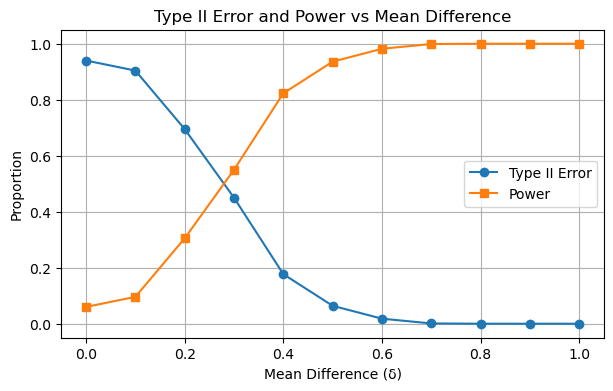

In [101]:
# Plot Type II error and power as a function of mean difference
plt.figure(figsize=(7,4))
plt.plot(mean_differences, type_ii_errors, marker='o', label="Type II Error")
plt.plot(mean_differences, power, marker='s', label="Power")
plt.xlabel("Mean Difference (δ)")
plt.ylabel("Proportion")
plt.title("Type II Error and Power vs Mean Difference")
plt.legend()
plt.grid(True)
plt.show()

As the difference in group means increases, the Type II error decreases while power increases.
For small mean differences, the test is more likely to fail to reject the null (higher Type II error), but as the groups become more distinct, the probability of correctly rejecting the null rises.
This demonstrates how sample size and effect size influence the sensitivity of t-tests.

*****

#### Interpretation:

- When the mean difference is small, the two distributions overlap heavily.
- The t-test struggles to detect a difference.
- The Type II error rate is high and power is low.
- As the mean difference increases, the distributions separate.
- The t-test detects differences more reliably.
- The Type II error rate decreases.
- Power increases toward 1.

This behavior is consistent with statistical theory: larger effect sizes lead to higher power.

- When δ = 0, the null hypothesis is true, so “Type II error” is not meaningful.
- For δ > 0, the null hypothesis is false, and failing to reject it constitutes a Type II error.

Increasing:

- sample size
- significance level
- or effect size
would further increase power.

****

#### Effect of Sample Size on Type II Error

##### Goal

Instead of fixing n = 100, we:
- Vary the sample size
- Examine how Type II error behaves for a fixed mean difference

In [102]:
# Reproducibility
np.random.seed(42)

# Simulation parameters
alpha = 0.05                # significance level             
n_simulations = 1000        # number of simulations
delta = 0.3                 # fixed mean difference
sample_sizes = [20, 50, 100, 200, 500]


In [103]:
def type_ii_error_rate(delta, n, n_simulations=1000, alpha=0.05):
    #Estimate Type II error rate for a given sample size.
    failures = 0
    
    for _ in range(n_simulations):
        x = np.random.normal(0, 1, n)
        y = np.random.normal(delta, 1, n)
        
        # Perform Student's t-test
        _, p = ttest_ind(x, y, equal_var=True)
        
        # Count failure to reject H0
        if p >= alpha:
            failures += 1
            
    return failures / n_simulations


In [104]:
# Compute Type II error rate for each sample size
type_ii_errors_n = np.array([
    type_ii_error_rate(delta, n) for n in sample_sizes
])

# Convert Type II error rates to power
power_n = 1 - type_ii_errors_n

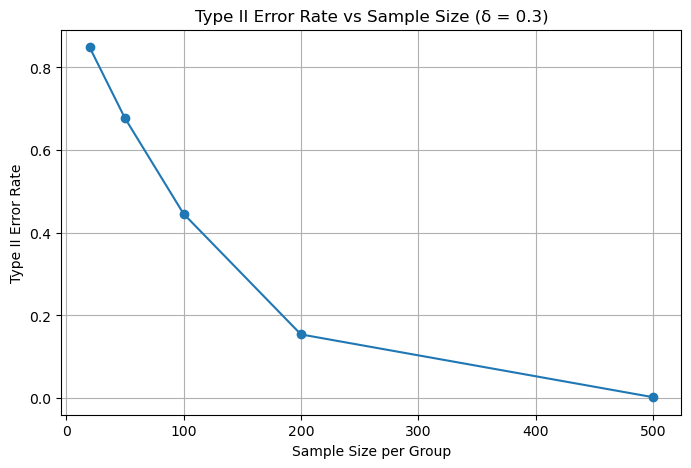

In [105]:

# Plot Type II error rate vs sample size

plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, type_ii_errors_n, marker='o')
plt.xlabel("Sample Size per Group")
plt.ylabel("Type II Error Rate")
plt.title(f"Type II Error Rate vs Sample Size (δ = {delta})")
plt.grid(True)
plt.show()


***

#### Interpretation

- For small sample sizes, sampling variability is large.
- The t-test often fails to detect the true difference.
- Type II error rate is high.

##### As the sample size increases:
- The sampling distribution becomes tighter.
- The test statistic increases in magnitude.
- Type II error decreases rapidly.

This demonstrates that power increases with sample size, even when the effect size remains fixed.

****

#### Student’s vs Welch’s t-test

##### Student’s t-test:
- Assumes equal variances in the two populations
- Uses a pooled variance estimate
- Slightly more powerful when the assumption is true

##### Welch’s t-test:
- Does not assume equal variances
- Uses separate variance estimates and adjusted degrees of freedom
- More robust when variances differ
- Default in many statistical packages

In [106]:
# Simulation parameters
np.random.seed(42)

n = 100
n_simulations = 1000
alpha = 0.05
delta = 0.3

# Population standard deviations
sigma_1 = 1.0
sigma_2 = 2.0    # unequal variance


In [107]:
def type_ii_error_rate_ttest(delta, n, sigma_1, sigma_2,
                             equal_var, n_simulations=1000, alpha=0.05):
#Estimate Type II error rate via Monte Carlo simulation.
    failures = 0
    
    for _ in range(n_simulations):
        # Generate samples
        x = np.random.normal(0, sigma_1, n)
        y = np.random.normal(delta, sigma_2, n)
        
        # Perform t-test (Student or Welch)
        _, p = ttest_ind(x, y, equal_var=equal_var)
        
        # Count failure to reject H0
        if p >= alpha:
            failures += 1
            
    return failures / n_simulations


In [108]:
# Type II error rates
type_ii_student = type_ii_error_rate_ttest(
    delta, n, sigma_1, sigma_2, equal_var=True
)

type_ii_welch = type_ii_error_rate_ttest(
    delta, n, sigma_1, sigma_2, equal_var=False
)


# Convert to power
power_student = 1 - type_ii_student
power_welch = 1 - type_ii_welch


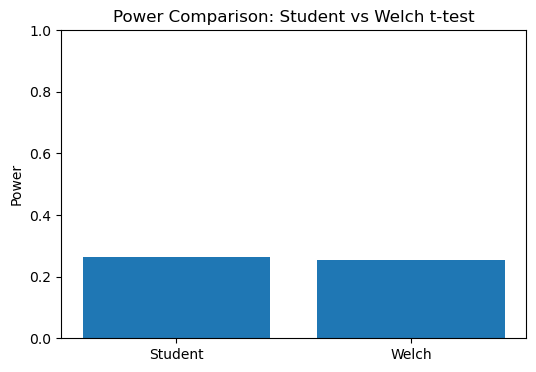

In [109]:

# Plot power comparison

labels = ["Student", "Welch"]
power_values = [power_student, power_welch]

plt.figure(figsize=(6, 4))
plt.bar(labels, power_values)
plt.ylabel("Power")
plt.title("Power Comparison: Student vs Welch t-test")
plt.ylim(0, 1)
plt.show()


****

#### Interpretation 

- When the equal variance assumption is violated, Student’s t-test can lose power.
- Welch’s t-test remains robust and often outperforms Student’s test in terms of power.

This supports the common recommendation to prefer Welch’s t-test in practice, especially when variance equality is uncertain.

Important Subtle Point:

If variances are actually equal, Student’s t-test may have slightly higher power — but the difference is usually negligible.


***

#### References:

- [T-tests code example](https://github.com/ianmcloughlin/applied-statistics/blob/main/materials/t-tests.ipynb)
- [Student vs Welsh t-test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)
- [Power Curve](https://matplotlib.org/stable/tutorials/pyplot.html)

## Problem 4: ANOVA

Generate three independent samples with means 0, 0.5, 1 and standard deviation 1. Perform one-way ANOVA and pairwise t-tests. Compare conclusions and discuss why ANOVA is preferred.
*****

In [110]:
# Set a random seed for reproducibility
np.random.seed(42)

# 1) Generate three independent samples (n=30 each)
n = 30
sample1 = np.random.normal(loc=0,   scale=1, size=n)
sample2 = np.random.normal(loc=0.5, scale=1, size=n)
sample3 = np.random.normal(loc=1,   scale=1, size=n)


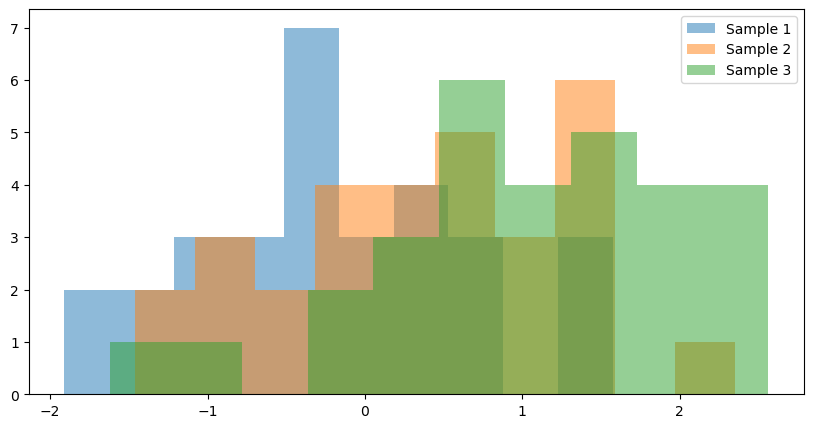

In [111]:
# Create histograms.
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram of the first sample.
ax.hist(sample1, bins=10, alpha=0.5, label='Sample 1')

# Histogram of the second sample.
ax.hist(sample2, bins=10, alpha=0.5, label='Sample 2')

# Histogram of the third sample.
ax.hist(sample3, bins=10, alpha=0.5, label='Sample 3')

# Add a legend.
ax.legend();

In [112]:
# Put in a DataFrame for statsmodels (long/tidy format)
df = pd.DataFrame({
    "value": np.concatenate([sample1, sample2, sample3]),
    "group": (["G1"] * n) + (["G2"] * n) + (["G3"] * n)
})

# Show first few rows
df.head()

,value,group
0,0.496714,G1
1,-0.138264,G1
2,0.647689,G1
3,1.523030,G1
4,-0.234153,G1


In [113]:
# One-way ANOVA
model = ols('value ~ C(group)', data=df).fit()
anova_table = anova_lm(model, typ=2)

print("=== One-way ANOVA ===")
print(anova_table)

=== One-way ANOVA ===
             sum_sq    df          F    PR(>F)
C(group)  21.659643   2.0  12.209526  0.000021
Residual  77.168804  87.0        NaN       NaN


In [114]:
# 3) Pairwise two-sample t-tests
t12 = stats.ttest_ind(sample1, sample2)
t13 = stats.ttest_ind(sample1, sample3)
t23 = stats.ttest_ind(sample2, sample3)

print("=== Pairwise t-tests ===")
print("Sample1 vs Sample2:", t12)
print("Sample1 vs Sample3:", t13)
print("Sample2 vs Sample3:", t23)

=== Pairwise t-tests ===
Sample1 vs Sample2: TtestResult(statistic=-2.398115152010245, pvalue=0.019717941865758044, df=58.0)
Sample1 vs Sample3: TtestResult(statistic=-4.911326340958337, pvalue=7.737964508099687e-06, df=58.0)
Sample2 vs Sample3: TtestResult(statistic=-2.5525907328394117, pvalue=0.013347246886682384, df=58.0)


****

### Why ANOVA is Preferred Over Several t-tests

Running multiple two-sample t-tests increases the familywise error rate: the more tests you do, the greater the chance of finding false positives just by chance.

ANOVA tests the global null hypothesis that all group means are equal using one overall test at a chosen significance level (e.g., 0.05), keeping the Type I error rate controlled.

If the ANOVA is significant, then post-hoc pairwise comparisons (with adjustments such as Tukey’s HSD) can be done. This approach avoids inflation of Type I error that would come from doing multiple unadjusted t-tests.

#### References:
 - [Anova Statistics](https://statistics.laerd.com/spss-tutorials/one-way-anova-using-spss-statistics.php)
 - [Base Code](https://github.com/ianmcloughlin/applied-statistics/blob/main/materials/anova.ipynb)
 - [Anova Stasmodel](https://www.geeksforgeeks.org/data-analysis/how-to-obtain-anova-table-with-statsmodels/)
 - [Example A](https://thequackdaddy.github.io/statsmodels.github.io/stable/generated/statsmodels.stats.anova.anova_lm.html)
 - [Example B](https://www.statsmodels.org/dev/anova.html) 

****
### Conclusion

This assessment explored fundamental concepts in applied statistics through simulation and inference:

1. Lady Tasting Tea Experiment (Problem 1)

- By extending the original 8-cup experiment to a 12-cup design, we demonstrated how the number of possible configurations affects the probability of correctly identifying all cups by chance.
- Monte Carlo simulations closely matched the exact combinatorial probabilities, confirming the validity of the simulation approach.
- Increasing the number of cups decreased the probability of a perfect guess, illustrating how design complexity influences evidence against the null hypothesis and p-value interpretation.

2. Normal Distribution and Standard Deviation Estimation (Problem 2)

- Simulating multiple small samples showed the bias of the population standard deviation estimator (ddof=0) compared to the unbiased sample standard deviation (ddof=1).
- As sample size increases, both estimators converge to the true population value, and the difference between them becomes negligible.
- This highlights the importance of Bessel’s correction for small samples and emphasizes how sampling variability decreases with larger samples.

3. Type II Error, Power, and t-Tests (Problem 3)

- Simulations of independent samples t-tests demonstrated how effect size (mean difference) and sample size affect Type II error and statistical power.
- Smaller mean differences or smaller sample sizes resulted in higher Type II error and lower power.
- Comparing Student’s and Welch’s t-tests showed that when population variances are unequal, Welch’s t-test is more robust and maintains higher power, supporting its general use in practice.
- Overall, these exercises illustrate how careful consideration of design parameters can improve the sensitivity of hypothesis tests and reduce the likelihood of Type II errors.

4. ANOVA vs Pairwise t-Tests (Problem 4)

- One-way ANOVA allowed testing for differences across multiple groups simultaneously while controlling the overall Type I error rate.
- Pairwise t-tests identified which specific groups differed, but running multiple t-tests without adjustment increases the risk of false positives.
- This comparison underscores why ANOVA is preferred for global tests across several groups before conducting post-hoc comparisons.

****
#### Key Takeaways

- Simulation as a Tool: Monte Carlo methods are powerful for understanding probabilities, error rates, and estimator behavior, especially when exact analytical solutions are complex.
- Design Matters: Sample size, effect size, and variance assumptions critically impact statistical inference.
- Bias and Variability: Small samples amplify bias and variability, making corrections like ddof=1 important for reliable estimation.
- Choosing the Right Test: Understanding assumptions (equality of variance, independence) guides whether Student, Welch, or ANOVA tests are appropriate.
- Visualization: Plots of distributions, Type II error curves, and power help convey the practical consequences of statistical decisions, reinforcing conceptual understanding.

#### Practical Advice for Applied Analysis

When designing experiments or analyzing data, it is essential to align statistical methods with the study design. Ensure that sample sizes are sufficient to detect meaningful effects, check assumptions such as variance equality, and use appropriate corrections for multiple comparisons when necessary. Simulations can be a powerful tool to anticipate potential errors and understand the behavior of estimators before collecting real data. Finally, visualizations are invaluable: they not only communicate results effectively but also help detect patterns, anomalies, and limitations in your analysis.


****

# End